In [15]:
# Setup notebook import path so src modules can be imported
import sys
import os

sys.path.append(
    os.path.abspath("../src")
)
print("✓ Added ../src to Python path")

✓ Added ../src to Python path


In [16]:
# Load the NuScenes dataset for camera perception
from data_loader import load_nuscenes

nusc = load_nuscenes()
print(f"✓ NuScenes loaded: {len(nusc.scene)} scenes available")

Loading nuScenes from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.123 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
✓ NuScenes loaded: 10 scenes available


In [17]:
# Select the first scene and the front camera sample for visualization
scene = nusc.scene[0]

sample = nusc.get(
    "sample",
    scene["first_sample_token"]
)

cam_token = (
    sample["data"]["CAM_FRONT"]
)

cam_data = nusc.get(
    "sample_data",
    cam_token
)

print(f"✓ Using scene: {scene['name']}")
print(f"✓ Camera sample token: {cam_token}")
print(f"✓ Camera filename: {cam_data['filename']}")

✓ Using scene: scene-0061
✓ Camera sample token: e3d495d4ac534d54b321f50006683844
✓ Camera filename: samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg


In [18]:
# Load the front camera image and convert from BGR to RGB for plotting
import os
import cv2

img_path = os.path.join(
    nusc.dataroot,
    cam_data["filename"]
)

image = cv2.imread(
    img_path
)
image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print(f"✓ Loaded camera image from: {img_path}")
print(f"✓ Image shape: {image.shape}")

✓ Loaded camera image from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
✓ Image shape: (900, 1600, 3)


In [19]:
# Run the perception pipeline on the loaded camera image
from perception.inference import PerceptionPipeline

pipeline = (
    PerceptionPipeline()
)

detections = (
    pipeline.run(image)
)

print(f"✓ Perception pipeline executed")
print(f"✓ Detected objects count: {len(detections)}")

✓ Perception pipeline executed
✓ Detected objects count: 7


In [20]:
# Print detection summary and show the first few detected objects
print(
    f"Objects Found: {len(detections)}"
)

sample_detections = detections[:3]
print("✓ First 3 detections:")
for i, det in enumerate(sample_detections, start=1):
    print(f"  {i}. class={det['class']}, bbox={det['bbox']}")
sample_detections

Objects Found: 7
✓ First 3 detections:
  1. class=truck, bbox=[125.26985168457031, 224.9639892578125, 599.7872924804688, 627.6463012695312]
  2. class=car, bbox=[1003.1649169921875, 494.63885498046875, 1076.613525390625, 535.4442749023438]
  3. class=bus, bbox=[716.6207885742188, 459.9169006347656, 786.9515991210938, 531.78662109375]


[{'class': 'truck',
  'confidence': 0.7717981934547424,
  'bbox': [125.26985168457031,
   224.9639892578125,
   599.7872924804688,
   627.6463012695312],
  'mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(384, 640), dtype=uint8)},
 {'class': 'car',
  'confidence': 0.5181732177734375,
  'bbox': [1003.1649169921875,
   494.63885498046875,
   1076.613525390625,
   535.4442749023438],
  'mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], shape=(384, 640), dtype=uint8)},
 {'class': 'bus',
  'confidence': 0.44239476323127747,
  'bbox': [716.6207885742188,
   459.9169006347656,
   786.9515991210938,
   531.78662109375],
  'mask': array([[0, 0,

✓ Rendered 7 detection boxes on image


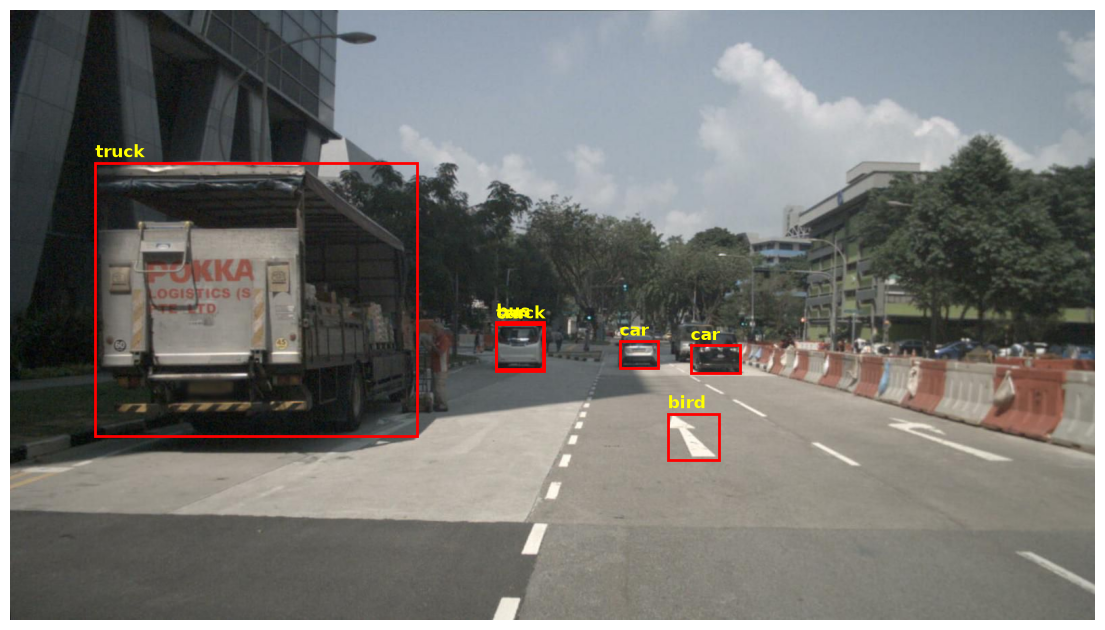

In [21]:
# Visualize detections by drawing bounding boxes on the image
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))
plt.imshow(image)

for det in detections:
    x1, y1, x2, y2 = det["bbox"]

    plt.gca().add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            fill=False,
            edgecolor="red",
            linewidth=2
        )
    )

    plt.text(
        x1,
        y1 - 8,
        det["class"],
        color="yellow",
        fontsize=12,
        weight="bold"
    )

plt.axis("off")
print(f"✓ Rendered {len(detections)} detection boxes on image")
plt.show()

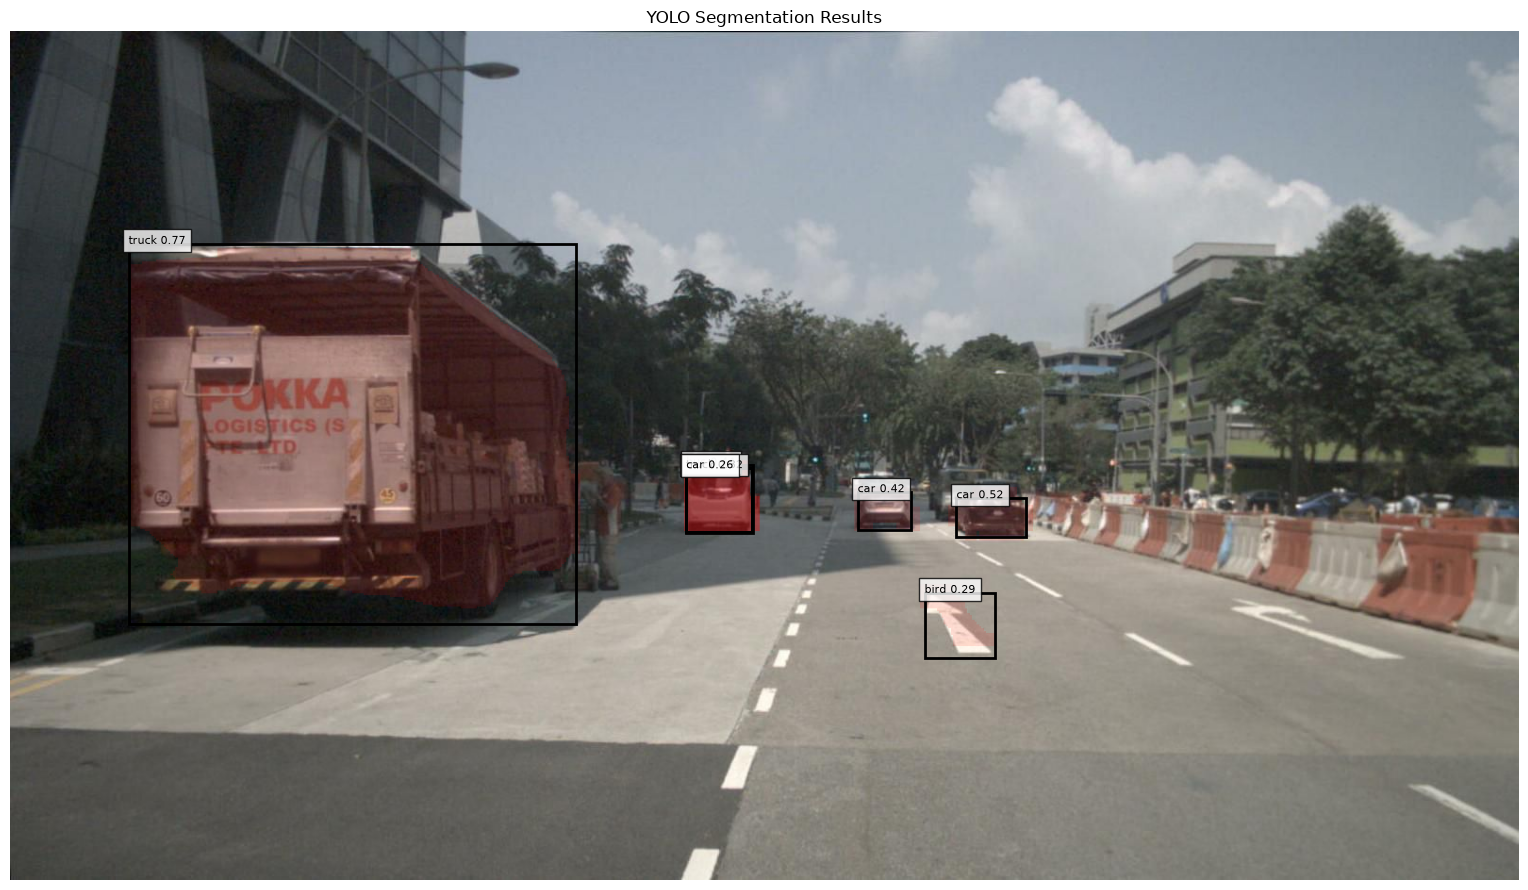

In [29]:
from visualization.perception_view import (
    visualize_detections
)

visualize_detections(
    image,
    detections,
    show_masks=True,
    save_path="../outputs/images/segmentation_result.png"
)